# Shadow
PyWake is capable of simulating the shadow cast by a wind turbine tower and rotor using a simplistic geometric model. This module enables detailed analysis of shadow effects for wind farm planning, environmental impact assessments, and regulatory compliance.

## Prerequisites
The shadow module requires additional dependencies beyond the core PyWake requirements:

**Intall PyWake if needed**

In [1]:
# Install PyWake if needed
try:
    import py_wake
except ModuleNotFoundError:
    !pip install git+https://gitlab.windenergy.dtu.dk/TOPFARM/PyWake.git

### Setting up the shadow simulations
First, import the necessary Python packages:

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from pyproj import Transformer

import py_wake
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from py_wake.site._site import UniformSite
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import CubePowerSimpleCt
from py_wake.flow_map import XYGrid, Points
from py_wake.shadow_models.shadow import ShadowModel
from py_wake.shadow_models.solar_position import solar_position
from py_wake.shadow_models.wind_direction import wind_rose, sun_facing_wind_direction

## Basic Shadow Modeling Workflow

The shadow modeling process follows three key steps:

### Step 1: Define the wind turbine

To run shadow calculations from an initial PyWake `SimulationResult`, you need a `WindTurbine` object with a `diameter`, `hub_height`, and a `tower_diameter`:

In [3]:
wt = WindTurbine(name="DemoWT",
                diameter=236,
                hub_height=150 ,
                powerCtFunction=CubePowerSimpleCt(ws_cutin=3, ws_cutout=25, ws_rated=12,
                                                power_rated=2000, power_unit='kW',
                                                ct=8/9, additional_models=[]),
                tower_diameter=10,
                )

### Step 2: Initialize the shadow model

Set up the wind farm layout, site, wake model, and time series, then create a shadow model from the simulation result:

In [4]:
x, y = [12.00, 12.02, 12.005, 12.01], [55.00, 55.02, 55.01, 55.02]
site = UniformSite()

wf_model = Bastankhah_PorteAgel_2014(site, wt, k=0.0324555)
time_series = pd.date_range("2024-01-01 00:00:00", "2024-12-31 23:59:59", freq="min", tz="Europe/Copenhagen")
wd = np.full(len(time_series), 0.0)
ws = np.ones_like(wd)
sim_res_time = wf_model(x, y, ws=ws, wd=wd, time=time_series)

# Initialize the shadow model from the PyWake simulation results
sm = sim_res_time.shadow_model(wind_direction=0)

# Or initialize the shadow model from scratch
sm = ShadowModel(
            src_x=x,
            src_y=y,
            src_h=150,
            turbine_diameter=236,
            tower_diameter=10,
            time=time_series,
            wind_direction=wd,
            min_sun_elevation=1,
            max_distance=4500
        )

### Solar position method, coordinate reference systems, and rotor orientation

Shadow calculations use `pvlib` for solar positions. The default method is `nrel_numpy`; use `solar_position_method` and `solar_position_kwargs` to select another pvlib method or pass method-specific settings.

Coordinates can be supplied in any CRS accepted by `pyproj`. By default, `calculation_crs="auto"` creates a local metre-based projection for the shadow geometry. You can also provide a projected CRS explicitly.

The `wind_direction` argument accepts a scalar, an explicit time series, a sampled wind rose, or `"sun_facing"` for per-turbine sun-facing rotor orientation. By default, the rotor center is placed at the tower center; use `rotor_offset` to specify a known horizontal tower-to-rotor-center offset in metres.

In [5]:
# Select another pvlib solar position method and use a uniform rotor orientation
sm = sim_res_time.shadow_model(
    wind_direction=0,
    solar_position_method="nrel_numpy",
    solar_position_kwargs={"temperature": 10},
)

# Sample timestamped wind directions from a wind rose
wind_rose_wd = np.linspace(0, 360, 12, endpoint=False)
wind_rose_f = [0, 0.039, 0.052, 0.07, 0, 0, 0, 0.118, 0.152, 0.147, 0.1, 0]
sm_wind_rose = sim_res_time.shadow_model(
    wind_direction={"type": "wind_rose", "wd": wind_rose_wd, "f": wind_rose_f, "seed": 1},
    solar_position_method="nrel_numpy",
)

# Orient each turbine rotor plane toward its own sun position
sm_sun_facing = sim_res_time.shadow_model(wind_direction="sun_facing")

# Apply a known rotor overhang explicitly, in metres
sm_offset = sim_res_time.shadow_model(wind_direction=0, rotor_offset=8.0)

# Use an explicit projected calculation CRS when desired
sm_projected = sim_res_time.shadow_model(
    src_crs="EPSG:4326",
    calculation_crs="EPSG:32633",
    solar_position_method="nrel_numpy",
)


### Step 3: Run the shadow simulation

Run the shadow calculations for a grid of points or specific receptors:

In [6]:
# For a grid (returns a ShadowMap)
res = sm.run(grid=XYGrid(x=np.linspace(11.95, 12.05, 30),
              y=np.linspace(54.90, 55.05, 30),
              h=0),
              rec_crs="EPSG:4326", 
              mode="rotor")  # "both" calculates shadows for both rotor and tower

# Or for specific points (returns a ShadowResult)
res_points = sm.run(grid=Points(x=[12.02, 12.03],
                               y=[55.021, 55.01],
                               h=[0, 0]), 
                    rec_crs="EPSG:4326", 
                    mode="combined") # "combined" calculates shadows for both rotor and tower

print(res)
print(res_points)

Processing: time 526001-527040/527040, receptors 1-900/900, turbines 1-4/4: 100%|██████████| 264/264 [00:09<00:00, 29.22it/s]
Processing: time 526001-527040/527040, receptors 1-2/2, turbines 1-4/4: 100%|██████████| 264/264 [00:00<00:00, 679.74it/s]


<xarray.ShadowMap> Size: 2GB
Dimensions:           (wt: 4, time: 527040, y: 30, x: 30)
Coordinates:
  * wt                (wt) int64 32B 0 1 2 3
  * time              (time) datetime64[us, Europe/Copenhagen] 4MB 2024-01-01...
  * y                 (y) float64 240B 54.9 54.91 54.91 ... 55.04 55.04 55.05
  * x                 (x) float64 240B 11.95 11.95 11.96 ... 12.04 12.05 12.05
Data variables:
    src_x             (wt) float64 32B 12.0 12.02 12.01 12.01
    src_y             (wt) float64 32B 55.0 55.02 55.01 55.02
    src_h             (wt) float64 32B 150.0 150.0 150.0 150.0
    turbine_diameter  (wt) float64 32B 236.0 236.0 236.0 236.0
    tower_diameter    (wt) float64 32B 10.0 10.0 10.0 10.0
    wind_direction    (time) float64 4MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Rotor shadow      (wt, y, x, time) bool 2GB False False ... False False
Attributes:
    created:                2026-06-02T20:17:07
    model:                  ShadowModel
    tz:                     Europe/

The result is either a `ShadowMap` (for grid points) or a `ShadowResult` (for specific points), containing shadow data that can be visualized and analyzed.

## Shadow Visualization

### Shadow Map

The `ShadowMap.plot()` method visualizes the spatial distribution of turbine shadows:

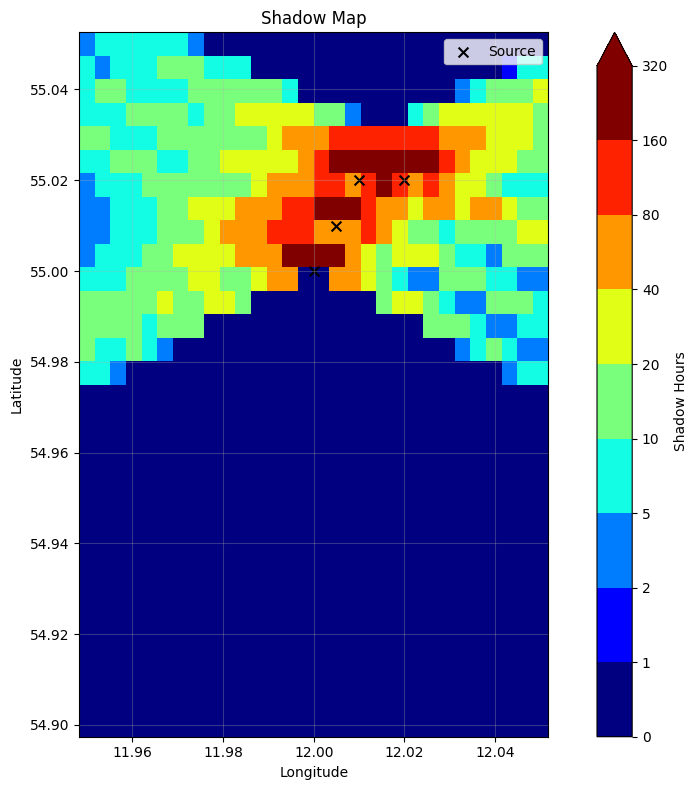

In [7]:
res.plot(figsize=(10, 8), cmap="jet", title="Shadow Map", 
         colorbar_label="Shadow Hours")
plt.show()

Parameters for `plot()` include:
- `rec_crs`: Coordinate reference system for the output map
- `mode`: Shadow calculation mode ("rotor", "tower", or "both")
- `cmap`: Colormap for shadow hours visualization
- `figsize`: Figure size in inches
- `title`: Plot title
- `colorbar_label`: Label for the colorbar
- `save_path`: Optional path to save the figure

### Shadow Calendar

Shadow calendars visualize when and where wind turbine shadows will affect specific receptor locations throughout the year:

Processing: time 526001-527040/527040, receptors 1-2/2, turbines 1-4/4: 100%|██████████| 264/264 [00:00<00:00, 653.90it/s]


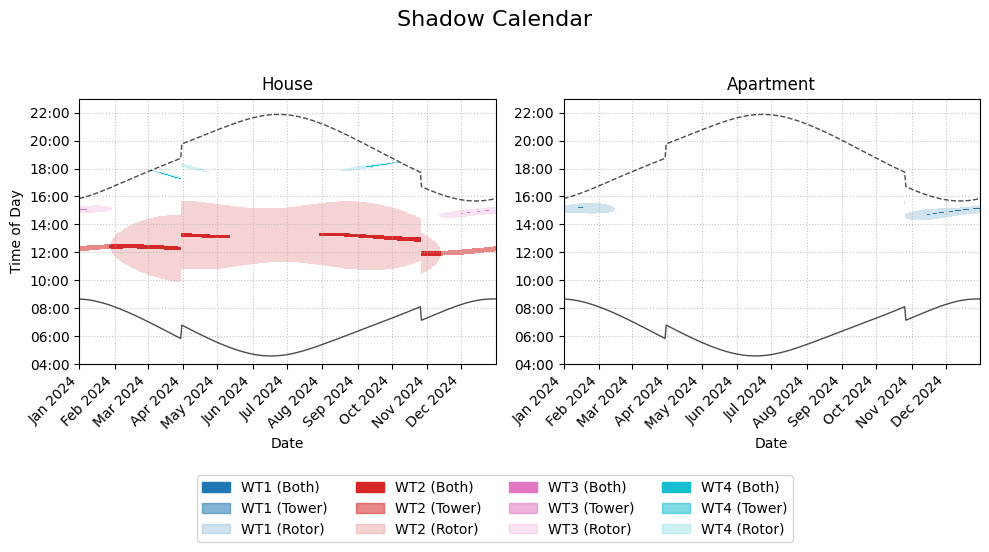

In [8]:
rec_x = [12.02, 12.01]
rec_y = [55.021, 55.007]
receptor_labels = ["House", "Apartment"]
turbine_labels = ["WT1", "WT2", "WT3", "WT4"]

# Run shadow simulation for specific points
res = sm.run(grid=Points(x=rec_x, y=rec_y, h=[0, 0]))

# Create shadow calendar
res.calendar(receptor_labels=receptor_labels, turbine_labels=turbine_labels, hour_range=(4, 23))
plt.show()

Parameters for `shadow_calendar()` include:
- `hour_range`: Custom hour range to display
- `figsize`: Figure dimensions in inches
- `title`: Title for the overall figure
- `save_path`: Path to save the figure
- `receptor_labels`: Custom labels for each receptor point
- `turbine_labels`: Custom labels for each turbine

## Filtering Shadow Results with `.sel()`

The shadow results can be filtered using the `.sel()` method to analyze specific time periods or turbines:

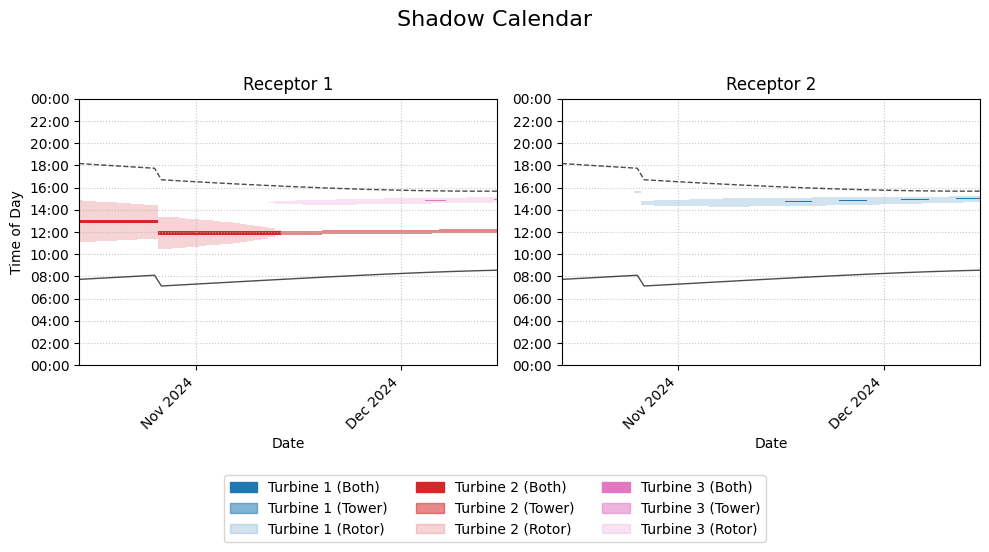

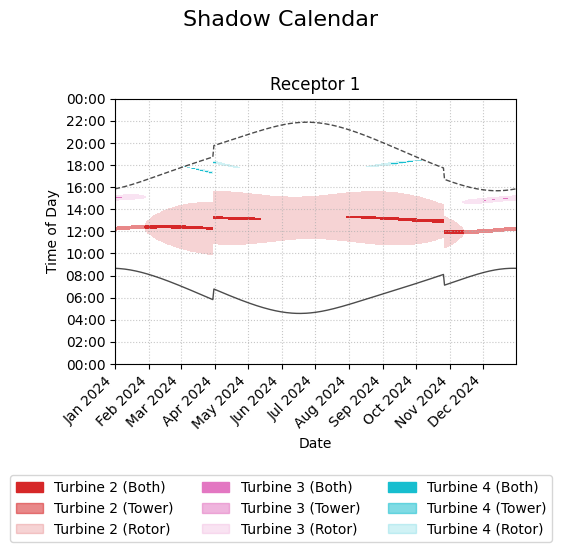

In [9]:
# Filter by time period
start = pd.Timestamp('2024-10-15 00:00:00', tz='Europe/Copenhagen')
end = pd.Timestamp('2024-12-15 23:59:59', tz='Europe/Copenhagen')
filtered_result = res.sel(time=slice(start, end))

# Create calendar for the filtered time period
filtered_result.calendar()

# Filter by specific receptors (for ShadowResult objects)
receptor_subset = res.sel(rec=[0])  # Select only the first receptor
receptor_subset.calendar()
plt.show()

### Shadow plot
To visualize the position of the receptors in the `ShadowResult`, the `plot` function can be used

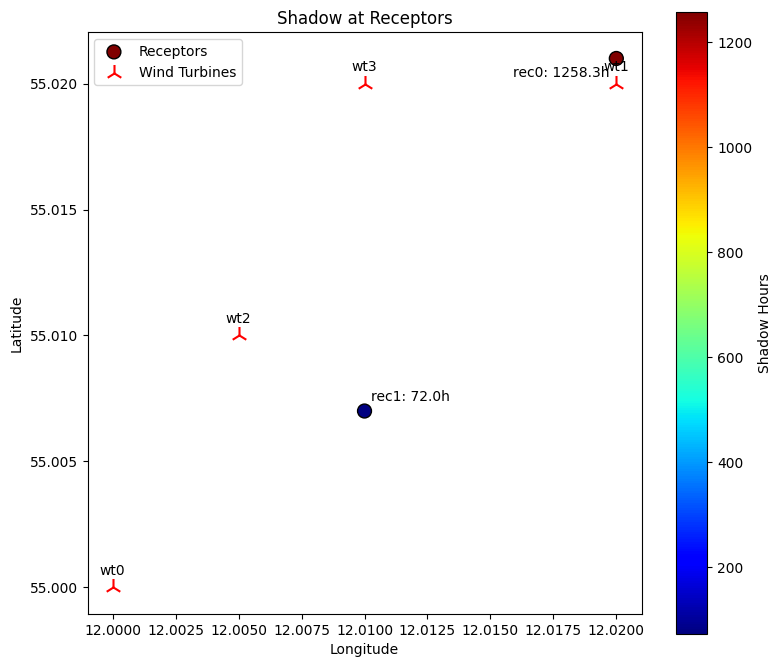

In [10]:
res.plot(figsize=(8, 7), cmap="jet", title="Shadow at Receptors")
plt.show()

## Animations

The shadow module can generate animations that illustrate shadow behavior over time:

In [ ]:
# Set up time series and shadow model
time_series = pd.date_range("2024-05-12 12:00:00", "2024-05-12 14:59:59", freq="min", tz="Europe/Copenhagen")
wd = np.full(len(time_series), 0.0)
ws = np.ones_like(wd)
sim_res_time = wf_model(x, y, ws=ws, wd=wd, time=time_series)

sm = sim_res_time.shadow_model("EPSG:4326", wind_direction="sun_facing")

utm_crs = "EPSG:32633"
to_utm = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
rec_x_utm, rec_y_utm = to_utm.transform(rec_x, rec_y)
corner_x, corner_y = to_utm.transform([11.99, 11.99, 12.03, 12.03],
                                       [54.99, 55.03, 54.99, 55.03])

# Run shadow simulation on the UTM grid
res = sm.run(grid=XYGrid(x=np.linspace(min(corner_x), max(corner_x), 300),
                         y=np.linspace(min(corner_y), max(corner_y), 300), h=0),
             rec_crs=utm_crs, mode="both")

folder = Path(py_wake.__file__).parent / '../docs/notebooks/images'
os.makedirs(folder, exist_ok=True)
fn = f'{folder}/Shadow.gif'
if not os.path.isfile(fn):
    with plt.ioff():
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(rec_x_utm, rec_y_utm, marker='x', color='red', label="Houses")
        res.animate(ax,
                    step=5,               # Show every 5th frame
                    interval=100,         # 100ms between frames
                    legend_position="bottom",
                    title="Demo Shadow Map (UTM zone 33N)",
                    xlabel="Easting [m]",
                    ylabel="Northing [m]",
                    save_path=fn)
        plt.close(fig)

<img src="images/Shadow.gif">

Parameters for `animate()` include:
- `ax`: Optional pre-existing axes (defaults to the current axes)
- `step`: Step size for time series sampling
- `interval`: Milliseconds between frames
- `save_path`: Path to save the animation
- `custom_colors`: Custom colors for shadow types
- `title`: Animation title
- `legend_position`: Position for the legend

You can also use `.sel()` with animations to create animations for specific time periods:

In [ ]:
start = pd.Timestamp('2024-05-12 13:00:00', tz='Europe/Copenhagen')
end = pd.Timestamp('2024-05-12 14:00:00', tz='Europe/Copenhagen')

fn = f'{folder}/Shadow_sel.gif'
if not os.path.isfile(fn):
    with plt.ioff():
        fig, ax = plt.subplots(figsize=(6, 6))
        res.sel(time=slice(start, end), wt=[0, 2]).animate(
            ax, title="Demo Shadow Map (UTM zone 33N)",
            xlabel="Easting [m]", ylabel="Northing [m]", save_path=fn)
        plt.close(fig)

<img src="images/Shadow_sel.gif">

## Saving and Loading Shadow Results

For large simulations, you can save and load the results to avoid recomputing:

```python
# Save shadow results
res.save("shadow_results.nc")
res_points.save("shadow_map.nc")

# Load shadow results
from py_wake.shadow_models.shadow import ShadowResult, ShadowMap
loaded_res = ShadowResult.load("shadow_results.nc")  # For point receptors
loaded_map = ShadowMap.load("shadow_map.nc")         # For grid maps
```

## Shadow Model Dimension Reduction Functions

### Explanation
The `collapse_*` functions are used to reduce the dimensionality of large shadow model datasets, which can be several gigabytes in size. Each function targets a specific dimension to simplify your data while preserving the essential shadow information.

### Example Usage

In [13]:
# Original data might be several GB
print(f"Original data size: {res.nbytes / 1e9:.2f} GB")

# Reduce dimensions one by one
res = (res
    .collapse_turbine()         # Combine all turbines using logical OR for shadow data
    .collapse_time()            # Sum shadow events across all timestamps 
    .collapse_shadow_type()     # Merge rotor and tower shadows into single shadow map
    )

# Data is now much smaller while preserving essential information
print(f"Reduced data size: {res.nbytes / 1e9:.2f} GB")
print(res)

Original data size: 1.44 GB
Reduced data size: 0.01 GB
<xarray.ShadowMap> Size: 8MB
Dimensions:           (wt: 1, x: 1000, y: 1000, time: 1)
Coordinates:
  * wt                (wt) int64 8B 0
  * x                 (x) float64 8kB 11.99 11.99 11.99 ... 12.03 12.03 12.03
  * y                 (y) float64 8kB 54.99 54.99 54.99 ... 55.03 55.03 55.03
Dimensions without coordinates: time
Data variables:
    src_x             (wt) float64 8B nan
    src_y             (wt) float64 8B nan
    src_h             (wt) float64 8B nan
    turbine_diameter  (wt) float64 8B nan
    tower_diameter    (wt) float64 8B nan
    wind_direction    (wt, time) float64 8B 0.0
    Combined shadow   (wt, y, x, time) int64 8MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes:
    created:                2026-06-02T20:17:48
    model:                  ShadowModel
    tz:                     Europe/Copenhagen
    freq:                   60.0
    src_crs:                EPSG:4326
    rec_crs:                EPSG:4326
    c



Each reduction step typically reduces memory usage significantly, making it easier to process and visualize the shadow effects from your wind turbines.

## Wind direction strategies
Shadow calculations accept wind direction strategies directly. Use a scalar for a uniform rotor orientation, a sampled wind rose for timestamped directions, or `"sun_facing"` to orient each turbine rotor plane toward its own sun position.

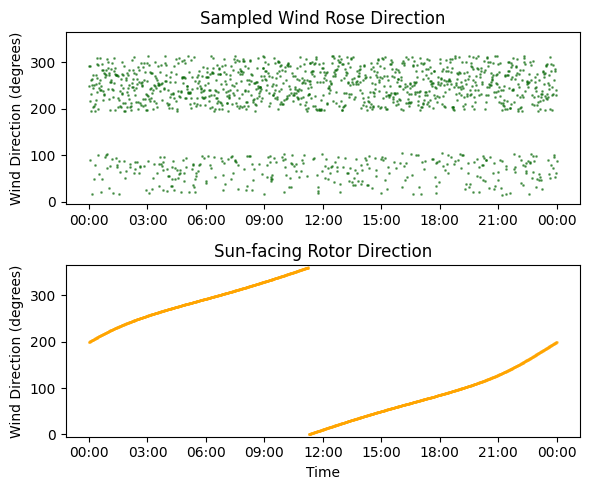

In [ ]:
# Setup data
dates = pd.date_range(start='2024-01-01', end='2024-01-02', freq='min')
time_series = pd.Series(dates)

# Wind rose data
f = [0, 0.039, 0.052, 0.07, 0, 0, 0, 0.118, 0.152, 0.147, 0.1, 0]
wd = np.linspace(0, 360, len(f), endpoint=False)

# Plot sampled wind rose directions and sun-facing directions
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5))

# Plot 1: Sampled wind rose direction
wind_angles = wind_rose(wd, f, len(time_series), seed=1)
ax1.scatter(dates, wind_angles, alpha=0.5, s=1, c='darkgreen')
ax1.set_ylabel('Wind Direction (degrees)')
ax1.set_title('Sampled Wind Rose Direction')
ax1.set_ylim(-5, 365)
ax1.xaxis.set_major_formatter(DateFormatter('%H:%M'))

# Plot 2: Sun-facing rotor direction
sun_vectors, celestial_coord = solar_position(dates, [55], [12])
sun_facing_angles = sun_facing_wind_direction(sun_vectors.squeeze())
ax2.scatter(dates, sun_facing_angles, alpha=0.5, s=1, c='orange')
ax2.set_xlabel('Time')
ax2.set_ylabel('Wind Direction (degrees)')
ax2.set_title('Sun-facing Rotor Direction')
ax2.set_ylim(-5, 365)
ax2.xaxis.set_major_formatter(DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


- `wind_direction=0`: Constant wind direction for all time steps
- `wind_direction={"type": "wind_rose", "wd": wd, "f": f, "seed": 1}`: Sample timestamped directions from a wind rose
- `wind_direction="sun_facing"`: Orient each turbine rotor plane toward its own sun position at each timestamp
- `wind_direction=array`: Use an explicit 1D time series or 2D per-turbine time series
